# Post-Hoc Reasoning Results Visualization

This notebook creates visualizations for parse rates and steering success rates across different alpha values.

In [7]:
import os
import json
import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import defaultdict
import pandas as pd

# Set style for cleaner plots
plt.style.use('default')  # Reset to default first
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['axes.edgecolor'] = '#CCCCCC'
plt.rcParams['axes.linewidth'] = 1.0
plt.rcParams['grid.color'] = '#EEEEEE'
plt.rcParams['grid.linestyle'] = '-'
plt.rcParams['grid.linewidth'] = 0.8

# Use clean system fonts that are widely available
# These fonts are similar to Lato (clean, modern sans-serif)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = [
    'Helvetica Neue',      # macOS (very clean, similar to Lato)
    'Arial',               # Windows/Mac/Linux (clean and widely available)
    'Liberation Sans',     # Linux (open source, clean design)
    'DejaVu Sans',        # Cross-platform (matplotlib default)
    'sans-serif'          # Generic fallback
]

# Optional: Use a slightly lighter font weight if available
plt.rcParams['font.weight'] = 'normal'

In [8]:
# Configuration
CACHE_DIR = Path("cache/experiments")
MODELS = [
    "google/gemma-2-2b-it",
    "google/gemma-2-9b-it", 
    "Qwen/Qwen2.5-3B-Instruct",
    "Qwen/Qwen2.5-7B-Instruct",
    "microsoft/Phi-3-small-8k-instruct",
    "meta-llama/Llama-2-7b-chat-hf",
    "deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B",
    "deepseek-ai/DeepSeek-R1-Distill-Qwen-7B"
]
DATASETS = ["anachronisms", "logical_deduction", "social_chemistry", "sports_understanding"]

In [9]:
def load_steering_results(model_path, dataset):
    """Load all steering results for a given model and dataset."""
    results = defaultdict(list)
    
    # Find the experiment directory
    model_dir = CACHE_DIR / model_path.replace("/", "_") / dataset
    if not model_dir.exists():
        return results
    
    # Find the split directory (assuming first one found)
    split_dirs = list(model_dir.glob("split_*"))
    if not split_dirs:
        return results
    
    split_dir = split_dirs[0]
    
    # Find the hash directory
    hash_dirs = [d for d in split_dir.iterdir() if d.is_dir() and d.name not in ["data", "metadata", "probes", "steering"]]
    if not hash_dirs:
        return results
    
    hash_dir = hash_dirs[0]
    steering_dir = hash_dir / "steering"
    
    if not steering_dir.exists():
        return results
    
    # Load all steering result files
    for file_path in steering_dir.glob("*.pkl"):
        # Parse filename to get alpha and direction
        filename = file_path.stem
        parts = filename.split("_")
        
        if "alpha" in filename:
            # Find alpha value
            alpha_idx = parts.index("alpha") + 1
            alpha = float(parts[alpha_idx])
            
            # For alpha=0, determine direction from filename
            if alpha == 0:
                if "yes" in filename:
                    direction = "yes"
                elif "no" in filename:
                    direction = "no"
                else:
                    continue  # Skip if direction unclear
            else:
                # For non-zero alpha, determine by sign
                direction = "yes" if alpha > 0 else "no"
            
            # Load the results
            with open(file_path, "rb") as f:
                data = pickle.load(f)
                results[direction].append((abs(alpha), data))
    
    return results

In [10]:
def calculate_metrics(steering_data):
    """Calculate no parse rate and steering success rate from steering results with confidence intervals."""
    if not steering_data:
        return 0.0, 0.0, 0.0, 0.0
    
    total = len(steering_data)
    valid_parses = sum(1 for item in steering_data if item.get('is_valid_parse', False))
    successes = sum(1 for item in steering_data if item.get('success', False))
    
    # No parse rate is 1 - parse rate
    no_parse_rate = 1 - (valid_parses / total) if total > 0 else 0.0
    # Success rate denominator is number of valid parses, not total
    success_rate = successes / valid_parses if valid_parses > 0 else 0.0
    
    # Calculate standard errors using binomial proportion formula
    # SE = sqrt(p * (1-p) / n)
    no_parse_se = np.sqrt(no_parse_rate * (1 - no_parse_rate) / total) if total > 0 else 0.0
    success_se = np.sqrt(success_rate * (1 - success_rate) / valid_parses) if valid_parses > 0 else 0.0
    
    # Convert to 95% confidence interval (1.96 * SE)
    no_parse_ci = 1.96 * no_parse_se
    success_ci = 1.96 * success_se
    
    # Ensure confidence intervals don't go below 0 or above 1
    # This is especially important for extreme rates near 0 or 1
    # The CI returned here is the half-width that will be added/subtracted from the rate
    # So we need to ensure rate - CI >= 0 and rate + CI <= 1
    success_ci = min(success_ci, success_rate, 1 - success_rate)
    no_parse_ci = min(no_parse_ci, no_parse_rate, 1 - no_parse_rate)
    
    return no_parse_rate, success_rate, no_parse_ci, success_ci

In [11]:
def create_bar_plots(model, dataset, direction_data, direction="yes"):
    """Create bar plots for steering success rate with no parse rate as a line."""
    if not direction_data:
        return None
    
    # Sort by alpha value
    direction_data.sort(key=lambda x: x[0])
    
    alphas = []
    no_parse_rates = []
    success_rates = []
    no_parse_errors = []
    success_errors = []
    
    for alpha, data in direction_data:
        no_parse_rate, success_rate, no_parse_ci, success_ci = calculate_metrics(data)
        alphas.append(alpha)
        no_parse_rates.append(no_parse_rate)
        success_rates.append(success_rate)
        no_parse_errors.append(no_parse_ci)
        success_errors.append(success_ci)
    
    # Create figure with white background
    fig, ax = plt.subplots(figsize=(10, 7))
    fig.patch.set_facecolor('white')
    ax.set_facecolor('white')
    
    # Bar positions
    x = np.arange(len(alphas))
    width = 0.8  # Make bars wider so they touch
    
    # Create bars for success rate with specified blue color (122, 173, 169) = #7AADA9
    bars = ax.bar(x, success_rates, width, 
                   yerr=success_errors, capsize=0,  # No caps on error bars
                   color='#7AADA9', alpha=0.9,  # Almost opaque (0.1 transparency)
                   edgecolor='#7AADA9', linewidth=1.5,
                   error_kw={'linewidth': 1.5, 'elinewidth': 1.5, 'color': '#808080'})  # Grey error bars
    
    # Add no parse rate as a dashed line with specified red (201, 88, 83) = #C95853
    line = ax.plot(x, no_parse_rates, '--', color='#C95853', linewidth=1.8,  # Using RGB(201, 88, 83)
                   marker='o', markersize=4, markerfacecolor='#C95853',  # Smaller dots filled with red
                   markeredgewidth=0, markeredgecolor='#C95853',
                   label='Failed Parse Rate', zorder=10)
    
    # Customize plot with regular font weight and black color
    ax.set_xlabel('α', fontsize=14, fontweight='normal', color='black')  # Changed to alpha symbol
    ax.set_ylabel('Rate', fontsize=14, fontweight='normal', color='black')
    
    # Format model name (take part after slash, replace dashes with spaces)
    model_display = model.split('/')[-1].replace('-', ' ')
    
    # Format dataset name (replace underscores with spaces)
    dataset_display = dataset.replace('_', ' ')
    
    # Format title with regular weight and black color
    ax.set_title(f'{model_display}\n{dataset_display}: {direction}', 
                 fontsize=16, fontweight='normal', color='black', pad=20)
    
    ax.set_xticks(x)
    ax.set_xticklabels([str(int(a)) if a.is_integer() else str(a) for a in alphas], 
                       fontsize=12, color='black')
    
    # Create custom legend - smaller and in top left
    from matplotlib.patches import Patch
    from matplotlib.lines import Line2D
    legend_elements = [
        Patch(facecolor='#7AADA9', edgecolor='#7AADA9', alpha=0.9, label='Steering Success Rate'),
        Line2D([0], [0], color='#C95853', linewidth=1.8, linestyle='--', 
               marker='o', markersize=4, markerfacecolor='#C95853', 
               markeredgewidth=0, markeredgecolor='#C95853', label='Failed Parse Rate')
    ]
    ax.legend(handles=legend_elements, loc='upper left', frameon=False,  # Top left, no frame
              fontsize=9, handlelength=1.5, handletextpad=0.5)  # Even smaller font and spacing
    
    # Set y-axis limits and ticks
    ax.set_ylim(-0.05, 1.05)
    ax.set_yticks(np.arange(0, 1.1, 0.2))
    ax.set_yticklabels([f'{y:.1f}' for y in np.arange(0, 1.1, 0.2)], 
                       fontsize=12, color='black')
    
    # Add dotted grey grid, slightly more visible
    ax.grid(True, axis='y', alpha=0.5, linestyle=':', linewidth=1.0, color='#808080')
    ax.set_axisbelow(True)
    
    # Remove all value labels (both for bars and line)
    # No labels on bars anymore
    # No labels on the red line anymore
    
    # Remove top and right spines for cleaner look
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Make remaining spines lighter
    ax.spines['bottom'].set_color('#CCCCCC')
    ax.spines['left'].set_color('#CCCCCC')
    
    plt.tight_layout()
    return fig


Processing google/gemma-2-2b-it - anachronisms...


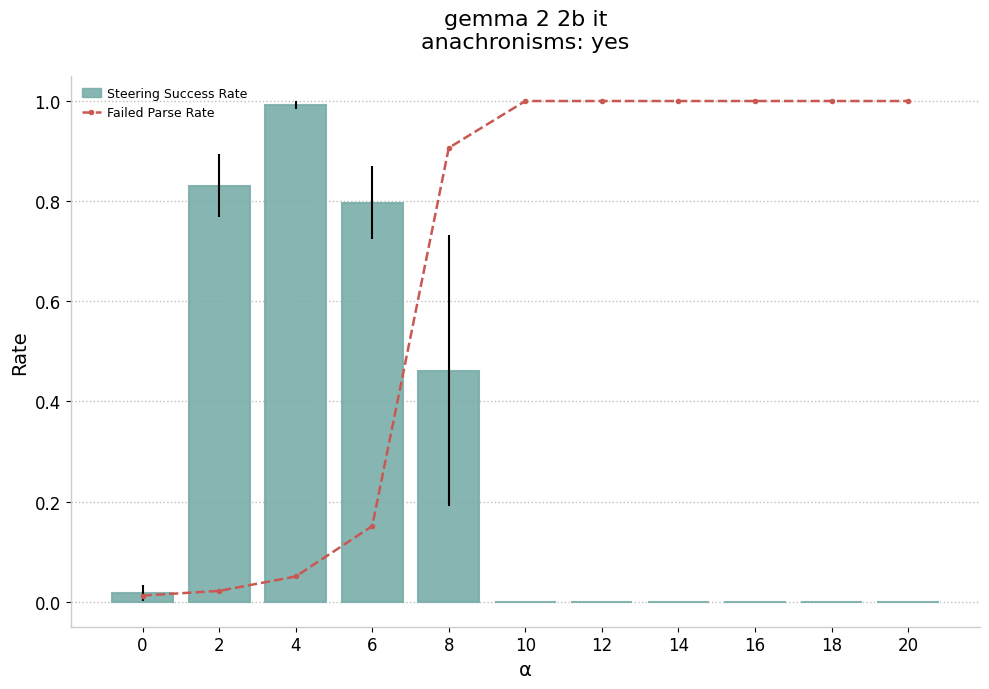

  Created yes direction plot


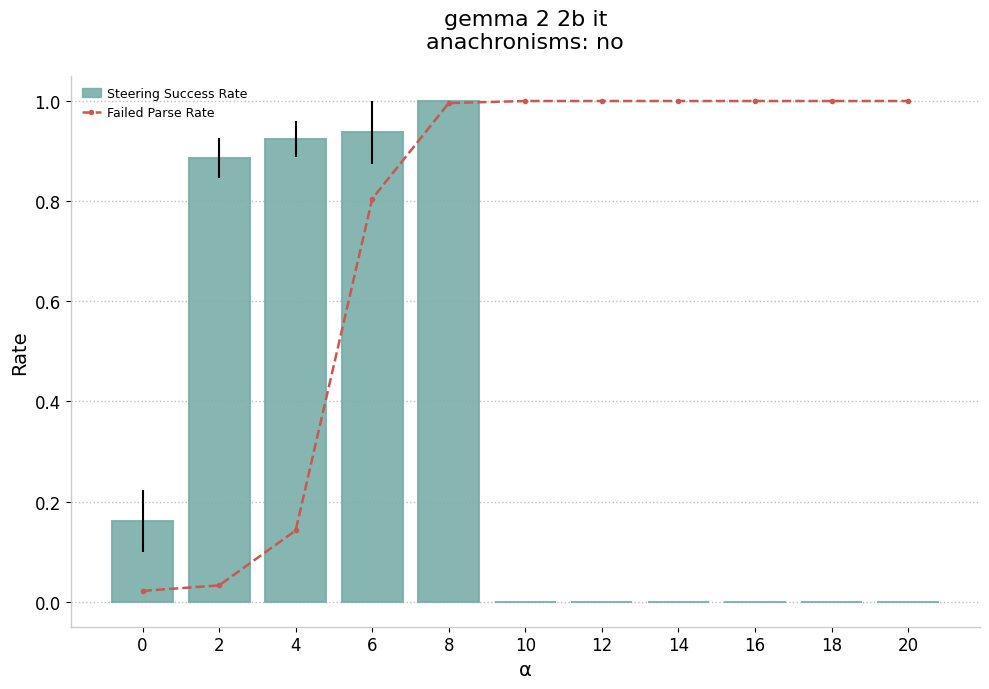

  Created no direction plot

Processing google/gemma-2-2b-it - logical_deduction...
  No steering results found

Processing google/gemma-2-2b-it - social_chemistry...
  No steering results found

Processing google/gemma-2-2b-it - sports_understanding...


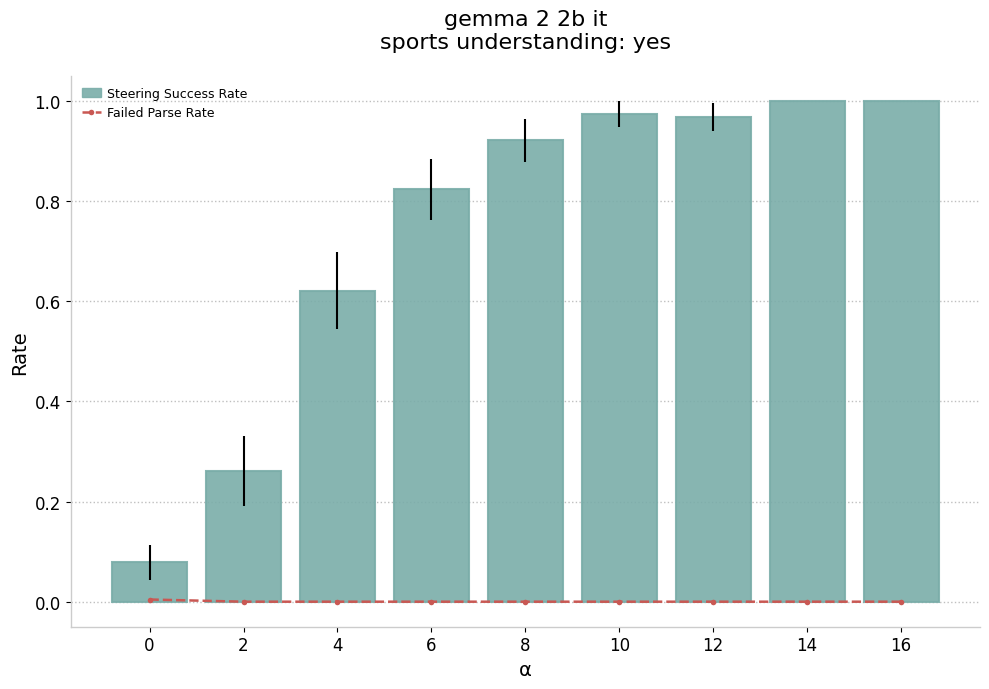

  Created yes direction plot


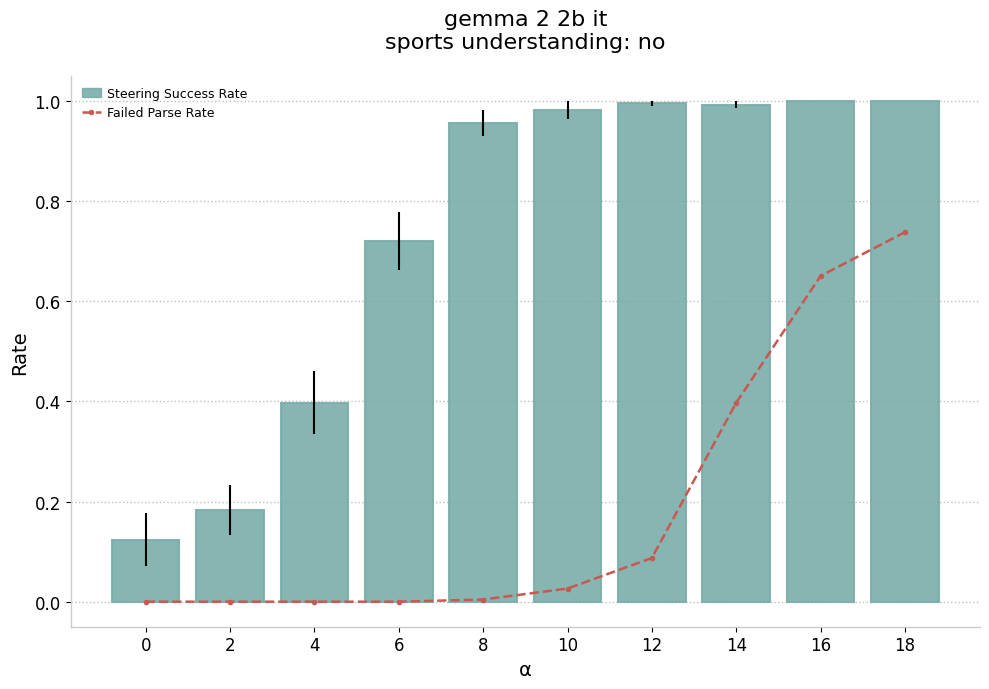

  Created no direction plot

Processing google/gemma-2-9b-it - anachronisms...
  No steering results found

Processing google/gemma-2-9b-it - logical_deduction...
  No steering results found

Processing google/gemma-2-9b-it - social_chemistry...
  No steering results found

Processing google/gemma-2-9b-it - sports_understanding...


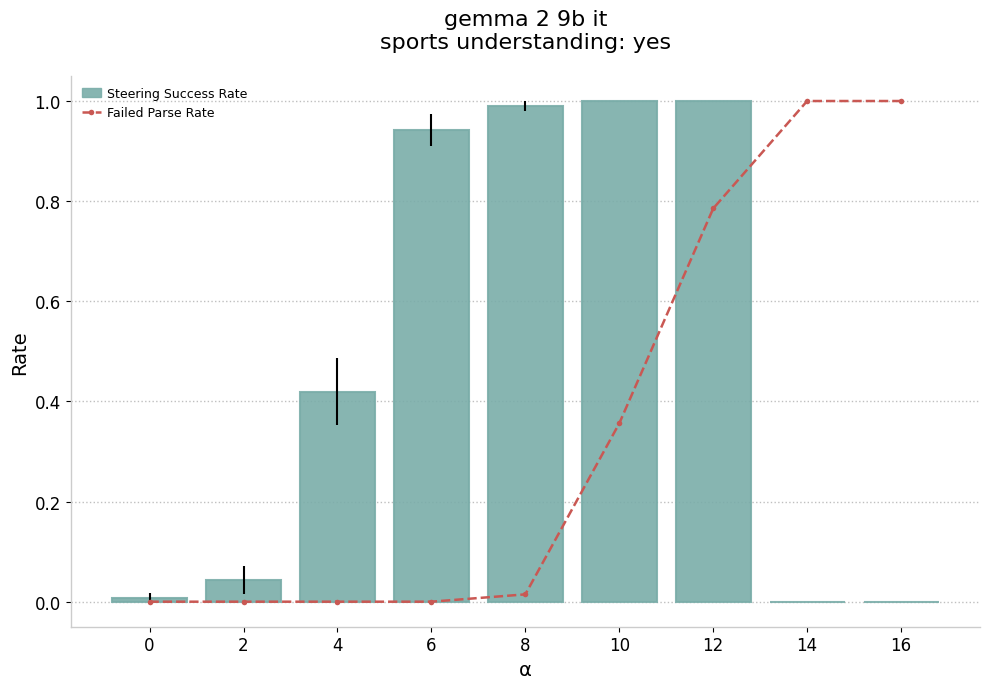

  Created yes direction plot


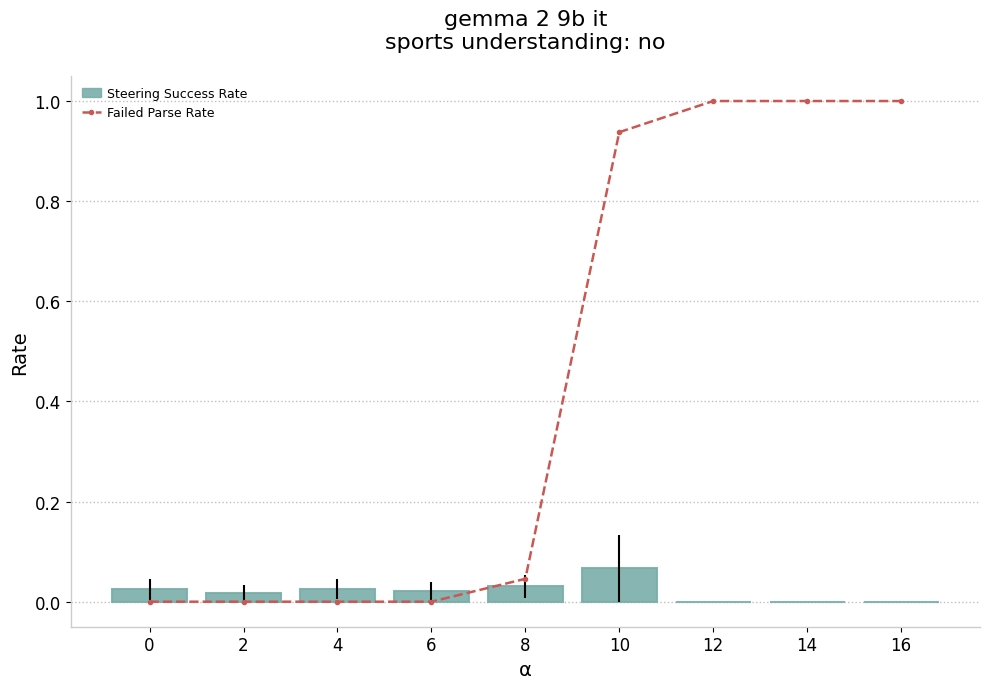

  Created no direction plot

Processing Qwen/Qwen2.5-3B-Instruct - anachronisms...
  No steering results found

Processing Qwen/Qwen2.5-3B-Instruct - logical_deduction...


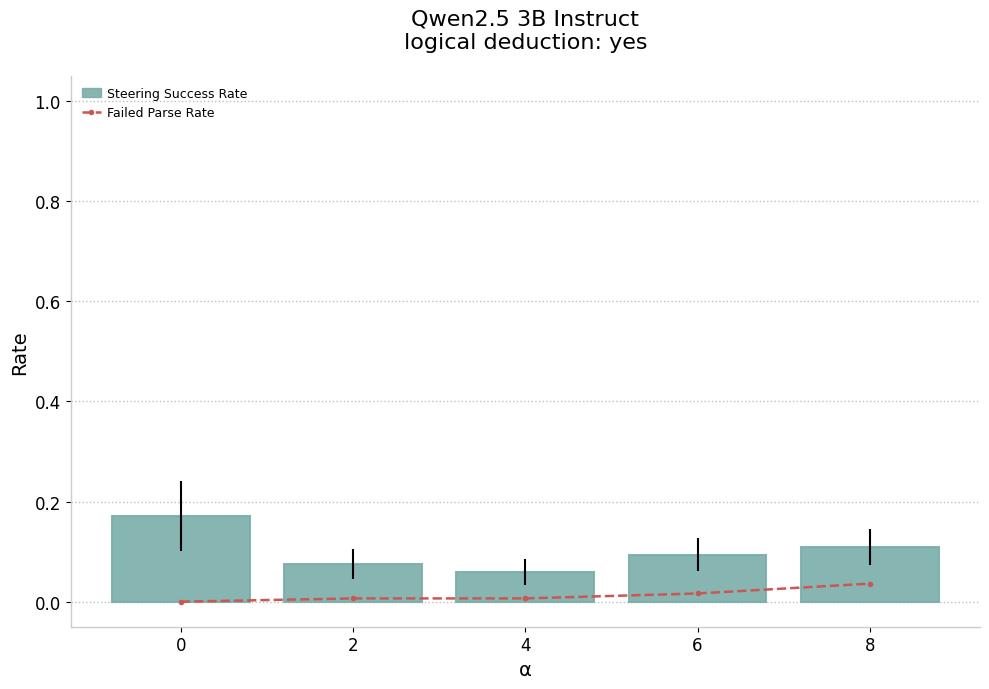

  Created yes direction plot


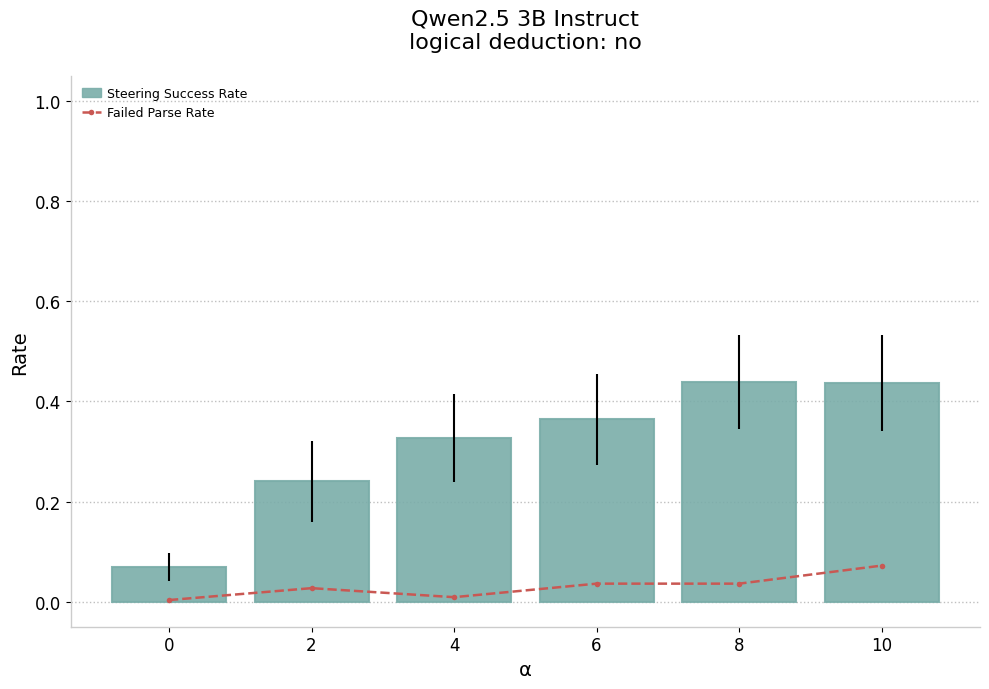

  Created no direction plot

Processing Qwen/Qwen2.5-3B-Instruct - social_chemistry...
  No steering results found

Processing Qwen/Qwen2.5-3B-Instruct - sports_understanding...


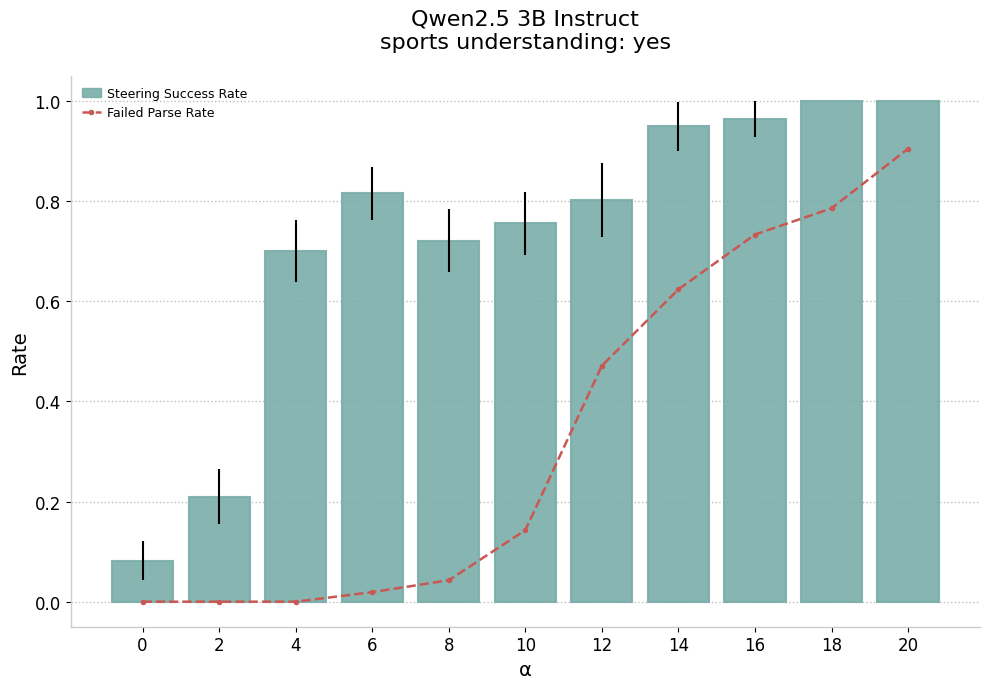

  Created yes direction plot


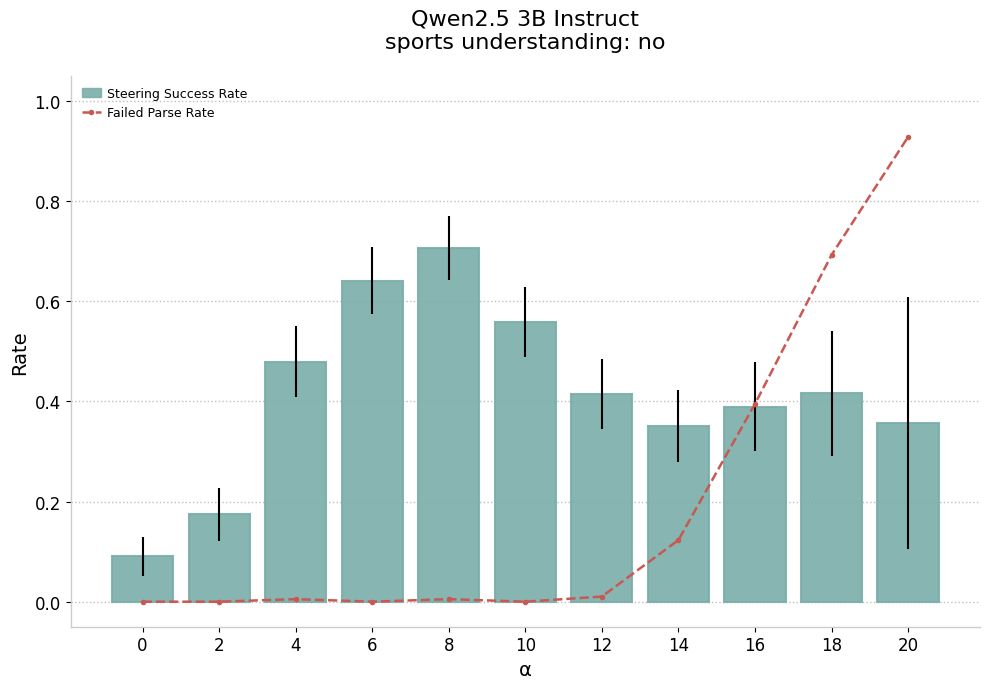

  Created no direction plot

Processing Qwen/Qwen2.5-7B-Instruct - anachronisms...


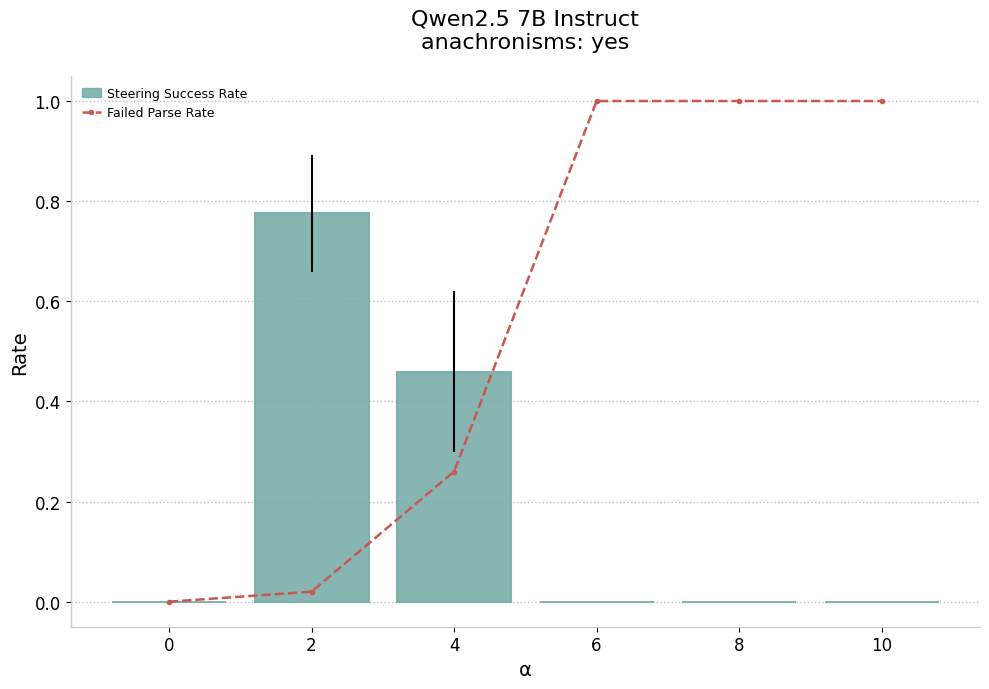

  Created yes direction plot


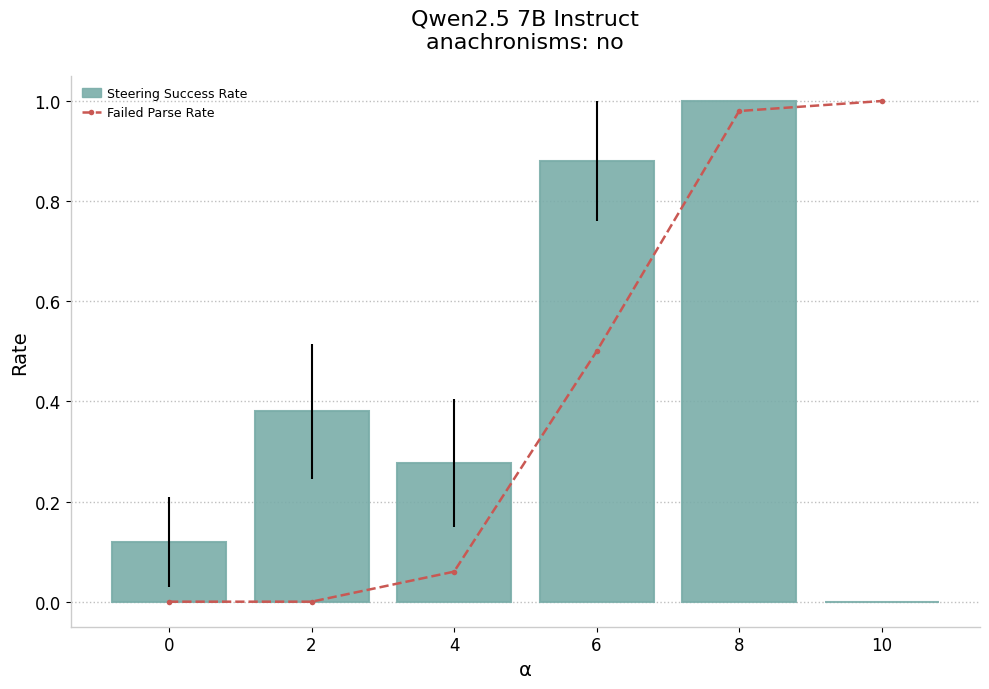

  Created no direction plot

Processing Qwen/Qwen2.5-7B-Instruct - logical_deduction...


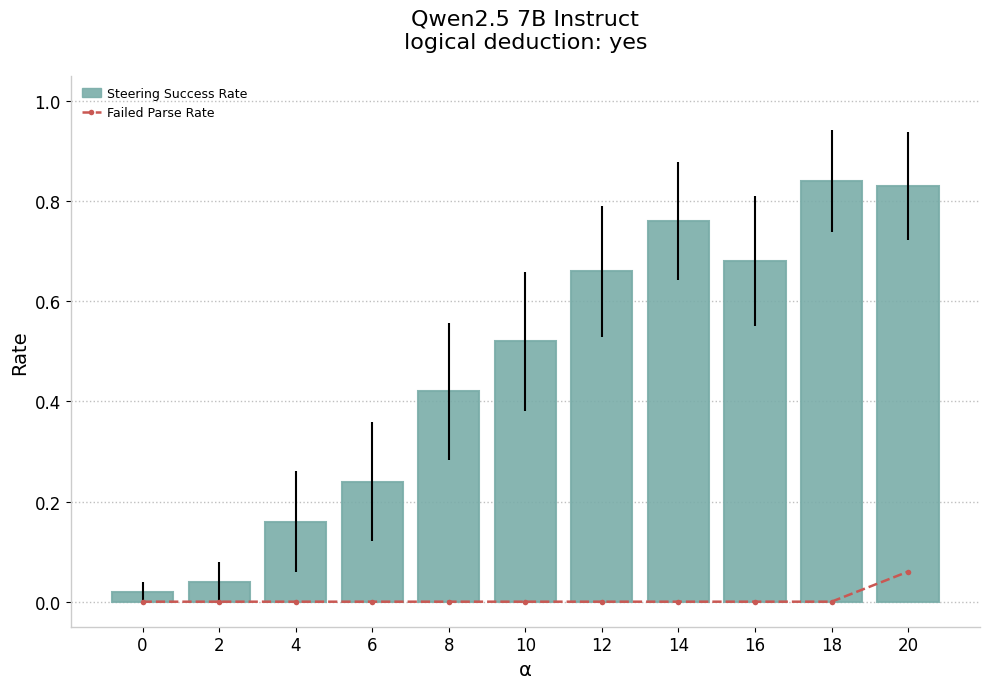

  Created yes direction plot


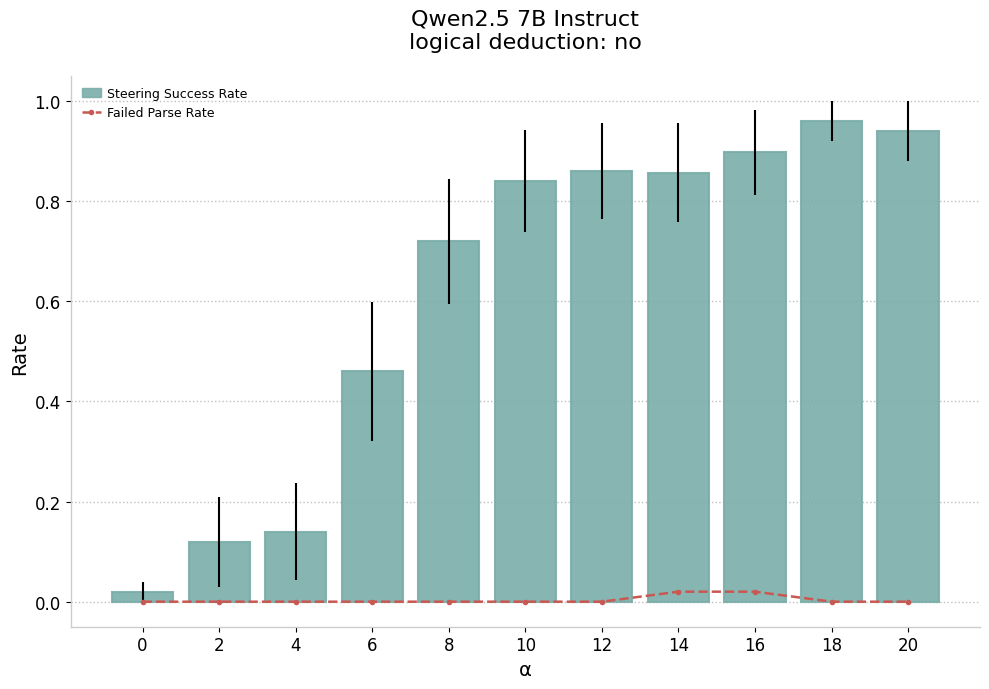

  Created no direction plot

Processing Qwen/Qwen2.5-7B-Instruct - social_chemistry...


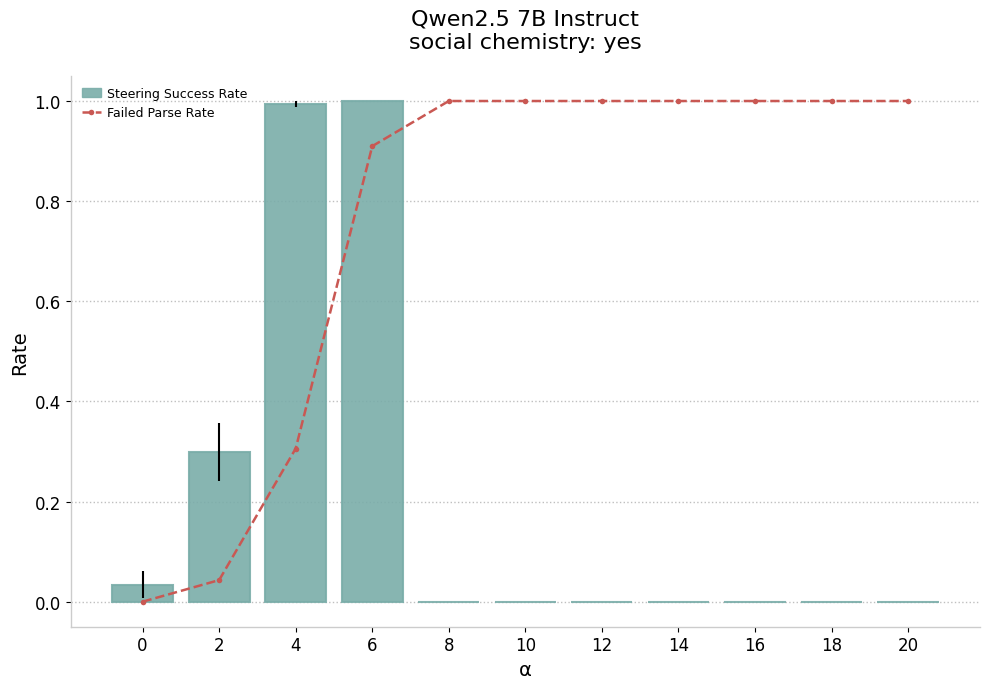

  Created yes direction plot


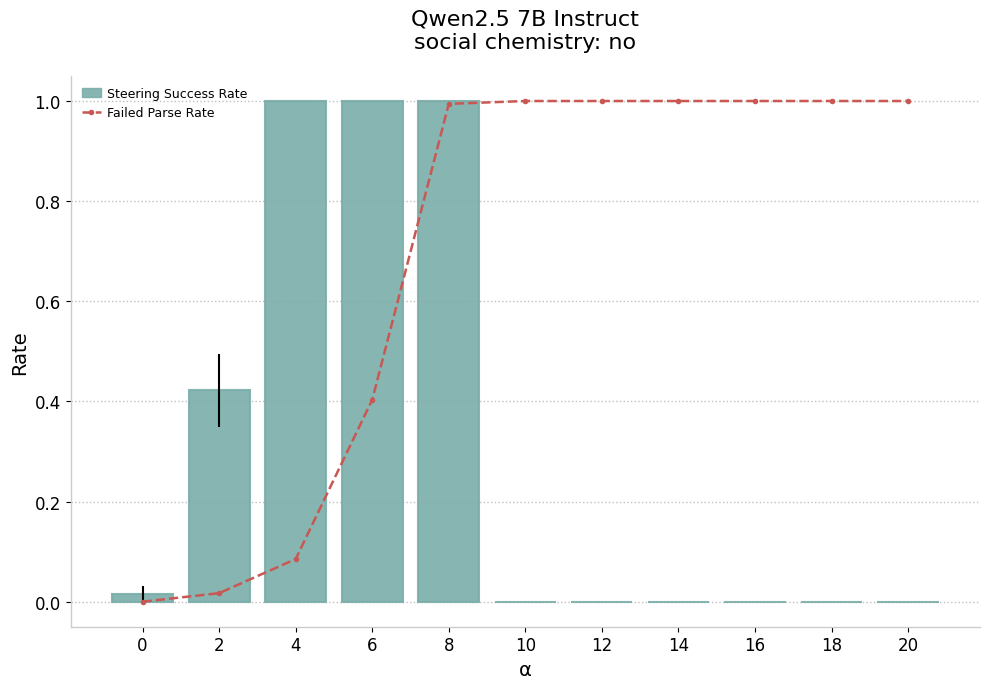

  Created no direction plot

Processing Qwen/Qwen2.5-7B-Instruct - sports_understanding...
  No steering results found

Processing microsoft/Phi-3-small-8k-instruct - anachronisms...
  No steering results found

Processing microsoft/Phi-3-small-8k-instruct - logical_deduction...
  No steering results found

Processing microsoft/Phi-3-small-8k-instruct - social_chemistry...
  No steering results found

Processing microsoft/Phi-3-small-8k-instruct - sports_understanding...
  No steering results found

Processing meta-llama/Llama-2-7b-chat-hf - anachronisms...
  No steering results found

Processing meta-llama/Llama-2-7b-chat-hf - logical_deduction...
  No steering results found

Processing meta-llama/Llama-2-7b-chat-hf - social_chemistry...
  No steering results found

Processing meta-llama/Llama-2-7b-chat-hf - sports_understanding...
  No steering results found

Processing deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B - anachronisms...
  No steering results found

Processing deepseek-ai/Dee

In [12]:
# Generate visualizations for all model-dataset combinations
all_figures = []

for model in MODELS:
    for dataset in DATASETS:
        print(f"\nProcessing {model} - {dataset}...")
        
        # Load steering results
        results = load_steering_results(model, dataset)
        
        if not results:
            print(f"  No steering results found")
            continue
        
        # Create plots for both directions
        for direction in ["yes", "no"]:
            if direction in results:
                fig = create_bar_plots(model, dataset, results[direction], direction)
                if fig:
                    all_figures.append((model, dataset, direction, fig))
                    plt.show()
                    print(f"  Created {direction} direction plot")
            else:
                print(f"  No {direction} direction data found")

In [13]:
# Save all figures to files
output_dir = Path("visualizations")
output_dir.mkdir(exist_ok=True)

for model, dataset, direction, fig in all_figures:
    filename = f"{model.replace('/', '_')}_{dataset}_{direction}.png"
    filepath = output_dir / filename
    fig.savefig(filepath, dpi=300, bbox_inches='tight')
    print(f"Saved: {filepath}")

Saved: visualizations/google_gemma-2-2b-it_anachronisms_yes.png
Saved: visualizations/google_gemma-2-2b-it_anachronisms_no.png
Saved: visualizations/google_gemma-2-2b-it_sports_understanding_yes.png
Saved: visualizations/google_gemma-2-2b-it_sports_understanding_no.png
Saved: visualizations/google_gemma-2-9b-it_sports_understanding_yes.png
Saved: visualizations/google_gemma-2-9b-it_sports_understanding_no.png
Saved: visualizations/Qwen_Qwen2.5-3B-Instruct_logical_deduction_yes.png
Saved: visualizations/Qwen_Qwen2.5-3B-Instruct_logical_deduction_no.png
Saved: visualizations/Qwen_Qwen2.5-3B-Instruct_sports_understanding_yes.png
Saved: visualizations/Qwen_Qwen2.5-3B-Instruct_sports_understanding_no.png
Saved: visualizations/Qwen_Qwen2.5-7B-Instruct_anachronisms_yes.png
Saved: visualizations/Qwen_Qwen2.5-7B-Instruct_anachronisms_no.png
Saved: visualizations/Qwen_Qwen2.5-7B-Instruct_logical_deduction_yes.png
Saved: visualizations/Qwen_Qwen2.5-7B-Instruct_logical_deduction_no.png
Saved: visu

In [14]:
# Create summary statistics
summary_data = []

for model in MODELS:
    for dataset in DATASETS:
        results = load_steering_results(model, dataset)
        
        if results:
            for direction in ["yes", "no"]:
                if direction in results:
                    for alpha, data in results[direction]:
                        no_parse_rate, success_rate, no_parse_ci, success_ci = calculate_metrics(data)
                        summary_data.append({
                            'Model': model.split('/')[-1],
                            'Dataset': dataset,
                            'Direction': direction,
                            'Alpha': alpha,
                            'No Parse Rate': no_parse_rate,
                            'Success Rate': success_rate,
                            'No Parse CI': no_parse_ci,
                            'Success CI': success_ci,
                            'N': len(data)
                        })

# Create DataFrame and display summary
if summary_data:
    df = pd.DataFrame(summary_data)
    print("\nSummary Statistics:")
    print(df.groupby(['Model', 'Dataset', 'Direction'])[['No Parse Rate', 'Success Rate']].agg(['mean', 'std', 'max']))


Summary Statistics:
                                                   No Parse Rate            \
                                                            mean       std   
Model               Dataset              Direction                           
Qwen2.5-3B-Instruct logical_deduction    no             0.030576  0.024513   
                                         yes            0.013115  0.014102   
                    sports_understanding no             0.196270  0.329900   
                                         yes            0.338528  0.367028   
Qwen2.5-7B-Instruct anachronisms         no             0.423333  0.477228   
                                         yes            0.546667  0.504962   
                    logical_deduction    no             0.003636  0.008090   
                                         yes            0.005455  0.018091   
                    social_chemistry     no             0.681818  0.452253   
                                         ye

# Probe AUC Visualization Section

In [15]:
def load_auc_scores(model_path, dataset):
    """Load AUC scores for a given model and dataset."""
    # Find the experiment directory
    model_dir = CACHE_DIR / model_path.replace("/", "_") / dataset
    if not model_dir.exists():
        return None
    
    # Find the split directory
    split_dirs = list(model_dir.glob("split_*"))
    if not split_dirs:
        return None
    
    split_dir = split_dirs[0]
    
    # Find the hash directory
    hash_dirs = [d for d in split_dir.iterdir() if d.is_dir() and d.name not in ["data", "metadata", "probes", "steering"]]
    if not hash_dirs:
        return None
    
    hash_dir = hash_dirs[0]
    auc_file = hash_dir / "probes" / "auc_scores.json"
    
    if not auc_file.exists():
        return None
    
    with open(auc_file, "r") as f:
        return json.load(f)

In [16]:
# Collect all AUC data
auc_data = []

for model in MODELS:
    for dataset in DATASETS:
        auc_scores = load_auc_scores(model, dataset)
        if auc_scores:
            # AUC scores are stored as a list of floats (one per layer)
            if isinstance(auc_scores, list) and len(auc_scores) > 0:
                # Find best AUC and its layer index
                best_auc = max(auc_scores)
                best_layer = auc_scores.index(best_auc)
                
                auc_data.append({
                    'Model': model,
                    'Model_Short': model.split('/')[-1],
                    'Dataset': dataset,
                    'Best_AUC': best_auc,
                    'Best_Layer': best_layer
                })
            elif isinstance(auc_scores, dict):
                # Handle dictionary format if it exists
                if 'best_auc' in auc_scores:
                    best_auc = auc_scores['best_auc']
                    best_layer = auc_scores.get('best_layer', 'Unknown')
                else:
                    # Find best AUC from layer scores
                    layer_scores = {k: v for k, v in auc_scores.items() if k.startswith('layer_')}
                    if layer_scores:
                        best_layer = max(layer_scores, key=layer_scores.get)
                        best_auc = layer_scores[best_layer]
                        best_layer = best_layer.replace('layer_', '')
                    else:
                        continue
                
                auc_data.append({
                    'Model': model,
                    'Model_Short': model.split('/')[-1],
                    'Dataset': dataset,
                    'Best_AUC': best_auc,
                    'Best_Layer': best_layer
                })

# Create DataFrame
auc_df = pd.DataFrame(auc_data)
print(f"Found AUC data for {len(auc_df)} model-dataset combinations")

Found AUC data for 9 model-dataset combinations


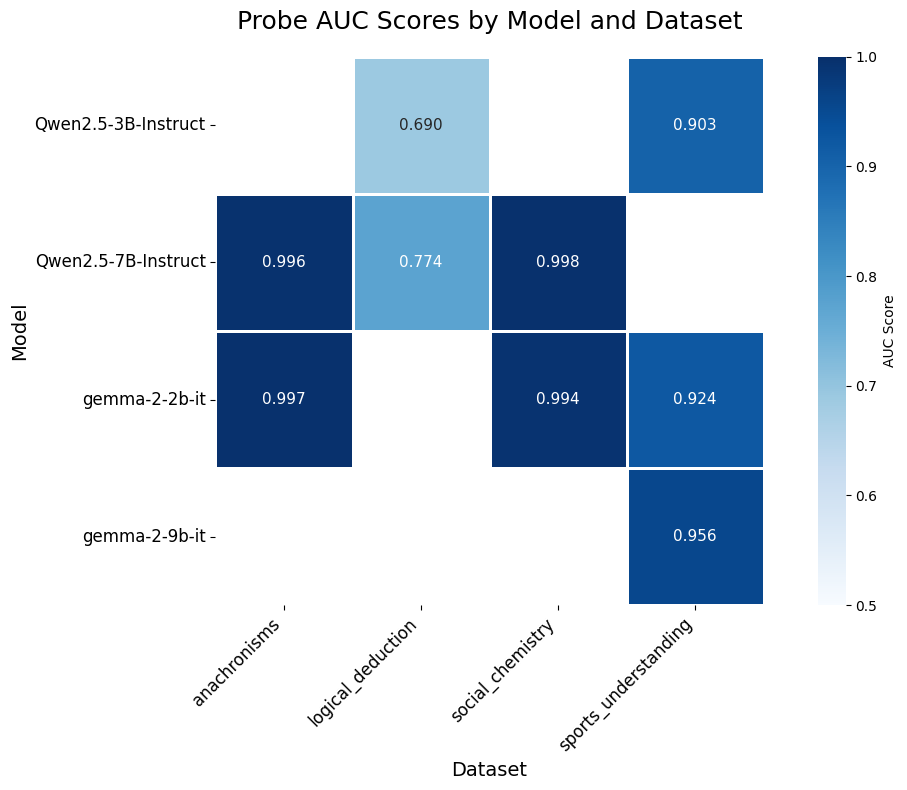

Saved AUC heatmap to visualizations/auc_heatmap.png


<Figure size 640x480 with 0 Axes>

In [17]:
# Create a heatmap of AUC scores
if not auc_df.empty:
    # Pivot the data for heatmap
    pivot_df = auc_df.pivot(index='Model_Short', columns='Dataset', values='Best_AUC')
    
    # Create figure with white background - BACK TO ORIGINAL SIZE
    plt.figure(figsize=(12, 8))  # Back to original
    fig = plt.gcf()
    fig.patch.set_facecolor('white')
    
    # Create heatmap with a better color scheme
    sns.heatmap(pivot_df, 
                annot=True, 
                fmt='.3f', 
                cmap='Blues',  # Use blues to match the bar charts
                vmin=0.5, 
                vmax=1.0,
                cbar_kws={'label': 'AUC Score'},
                square=True,
                linewidths=1,
                linecolor='white',
                annot_kws={'fontsize': 11, 'fontweight': 'normal'})  # Back to original
    
    plt.title('Probe AUC Scores by Model and Dataset', 
              fontsize=18, fontweight='normal', pad=20, color='black')  # Back to original
    plt.xlabel('Dataset', fontsize=14, fontweight='normal', color='black')  # Back to original
    plt.ylabel('Model', fontsize=14, fontweight='normal', color='black')  # Back to original
    plt.xticks(rotation=45, ha='right', fontsize=12, color='black')  # Back to original
    plt.yticks(rotation=0, fontsize=12, color='black')  # Back to original
    
    # Remove the default box around the plot
    ax = plt.gca()
    for spine in ax.spines.values():
        spine.set_visible(False)
    
    plt.tight_layout()
    plt.show()
    
    # Save the heatmap
    plt.savefig('visualizations/auc_heatmap.png', dpi=300, bbox_inches='tight', facecolor='white')
    print("Saved AUC heatmap to visualizations/auc_heatmap.png")

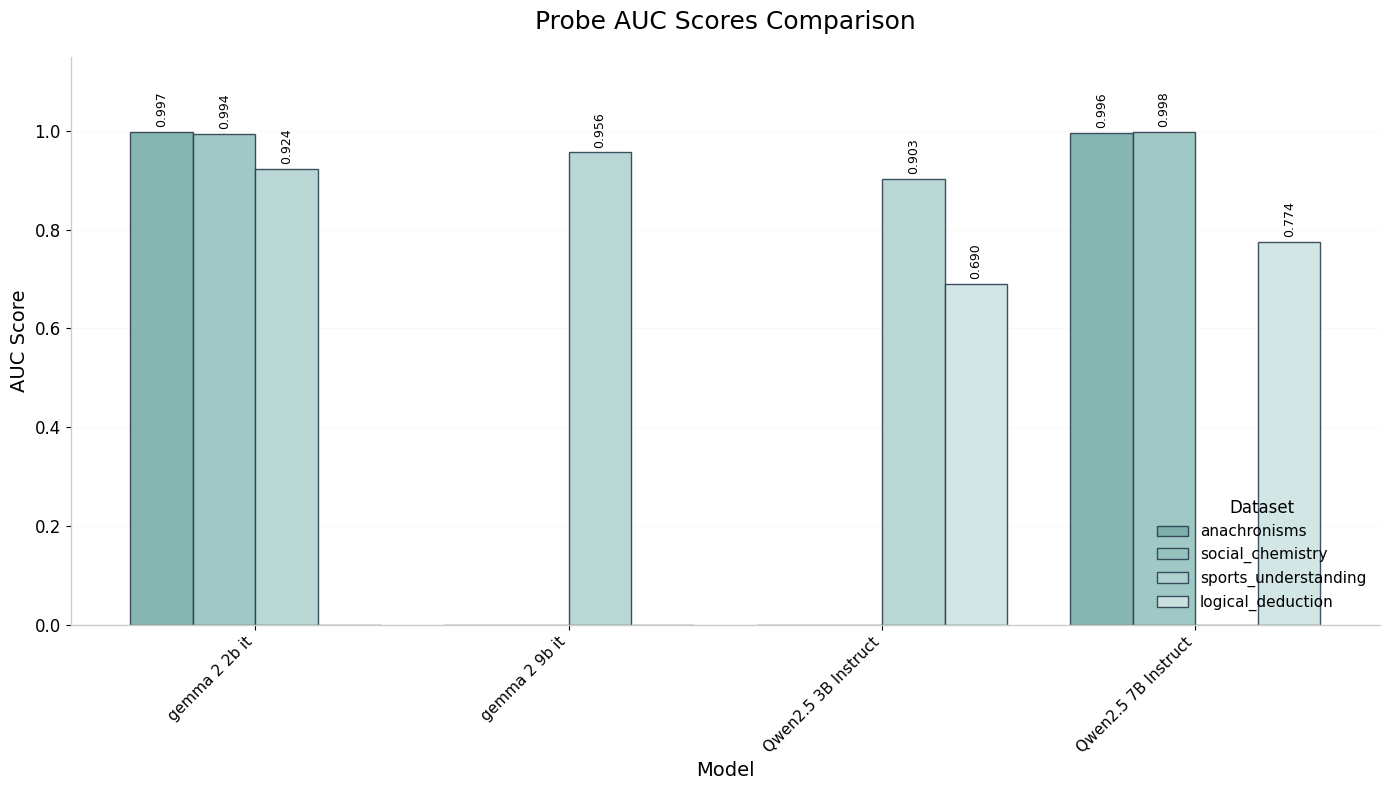

Saved AUC comparison bar chart to visualizations/auc_comparison_bars.png


<Figure size 640x480 with 0 Axes>

In [18]:
# Create bar chart comparing models across datasets
if not auc_df.empty:
    fig, ax = plt.subplots(figsize=(14, 8))  # Back to original
    fig.patch.set_facecolor('white')
    ax.set_facecolor('white')
    
    # Get unique models and datasets
    models = auc_df['Model_Short'].unique()
    datasets = auc_df['Dataset'].unique()
    
    # Set up bar positions
    x = np.arange(len(models))
    width = 0.2
    offsets = np.linspace(-width*1.5, width*1.5, len(datasets))
    
    # Color palette - variations of the new blue (122, 173, 169)
    colors = ['#7AADA9', '#96C3BF', '#B2D4D1', '#CEE5E3']
    
    # Create bars for each dataset
    for i, dataset in enumerate(datasets):
        dataset_data = auc_df[auc_df['Dataset'] == dataset]
        values = []
        for model in models:
            model_data = dataset_data[dataset_data['Model_Short'] == model]
            if not model_data.empty:
                values.append(model_data['Best_AUC'].iloc[0])
            else:
                values.append(0)  # Missing data
        
        bars = ax.bar(x + offsets[i], values, width, 
                      label=dataset, alpha=0.9,  # Almost opaque (0.1 transparency)
                      color=colors[i % len(colors)],
                      edgecolor='#2C3E50', linewidth=1)
        
        # Add value labels
        for bar, value in zip(bars, values):
            if value > 0:
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                       f'{value:.3f}', ha='center', va='bottom', 
                       fontsize=9, rotation=90, fontweight='normal', color='black')  # Back to original
    
    ax.set_xlabel('Model', fontsize=14, fontweight='normal', color='black')  # Back to original
    ax.set_ylabel('AUC Score', fontsize=14, fontweight='normal', color='black')  # Back to original
    ax.set_title('Probe AUC Scores Comparison', fontsize=18, fontweight='normal', pad=20, color='black')  # Back to original
    ax.set_xticks(x)
    ax.set_xticklabels([m.replace('-', ' ') for m in models], 
                       rotation=45, ha='right', fontsize=11, color='black')  # Back to original
    
    # Improve legend - place inside plot area
    ax.legend(title='Dataset', loc='lower right',
              frameon=False, fontsize=11,  # No frame, back to original size
              title_fontsize=12)
    
    ax.set_ylim(0, 1.15)
    
    # Add subtle grid
    ax.grid(True, axis='y', alpha=0.3, linestyle='-', linewidth=0.8)
    ax.set_axisbelow(True)
    
    # Remove top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_color('#CCCCCC')
    ax.spines['left'].set_color('#CCCCCC')
    
    # Set y-ticks
    ax.set_yticks(np.arange(0, 1.2, 0.2))
    ax.set_yticklabels([f'{y:.1f}' for y in np.arange(0, 1.2, 0.2)], 
                       fontsize=12, color='black')  # Back to original
    
    plt.tight_layout()
    plt.show()
    
    # Save the bar chart
    plt.savefig('visualizations/auc_comparison_bars.png', dpi=300, bbox_inches='tight', facecolor='white')
    print("Saved AUC comparison bar chart to visualizations/auc_comparison_bars.png")

In [19]:
# Display summary statistics for AUC scores
if not auc_df.empty:
    print("\nAUC Score Summary Statistics:")
    print("-" * 50)
    
    # Overall statistics
    print(f"\nOverall AUC: {auc_df['Best_AUC'].mean():.3f} ± {auc_df['Best_AUC'].std():.3f}")
    print(f"Best AUC: {auc_df['Best_AUC'].max():.3f}")
    print(f"Worst AUC: {auc_df['Best_AUC'].min():.3f}")
    
    # By model
    print("\nBy Model:")
    model_stats = auc_df.groupby('Model_Short')['Best_AUC'].agg(['mean', 'std', 'count'])
    for model, stats in model_stats.iterrows():
        print(f"  {model}: {stats['mean']:.3f} ± {stats['std']:.3f} (n={int(stats['count'])})")
    
    # By dataset
    print("\nBy Dataset:")
    dataset_stats = auc_df.groupby('Dataset')['Best_AUC'].agg(['mean', 'std', 'count'])
    for dataset, stats in dataset_stats.iterrows():
        print(f"  {dataset}: {stats['mean']:.3f} ± {stats['std']:.3f} (n={int(stats['count'])})")
    
    # Best performing model-dataset combinations
    print("\nTop 5 Model-Dataset Combinations:")
    top_combos = auc_df.nlargest(5, 'Best_AUC')[['Model_Short', 'Dataset', 'Best_AUC', 'Best_Layer']]
    for _, row in top_combos.iterrows():
        print(f"  {row['Model_Short']} - {row['Dataset']}: {row['Best_AUC']:.3f} (Layer {row['Best_Layer']})")


AUC Score Summary Statistics:
--------------------------------------------------

Overall AUC: 0.915 ± 0.111
Best AUC: 0.998
Worst AUC: 0.690

By Model:
  Qwen2.5-3B-Instruct: 0.796 ± 0.151 (n=2)
  Qwen2.5-7B-Instruct: 0.923 ± 0.129 (n=3)
  gemma-2-2b-it: 0.971 ± 0.042 (n=3)
  gemma-2-9b-it: 0.956 ± nan (n=1)

By Dataset:
  anachronisms: 0.997 ± 0.001 (n=2)
  logical_deduction: 0.732 ± 0.060 (n=2)
  social_chemistry: 0.996 ± 0.003 (n=2)
  sports_understanding: 0.928 ± 0.027 (n=3)

Top 5 Model-Dataset Combinations:
  Qwen2.5-7B-Instruct - social_chemistry: 0.998 (Layer 20)
  gemma-2-2b-it - anachronisms: 0.997 (Layer 14)
  Qwen2.5-7B-Instruct - anachronisms: 0.996 (Layer 19)
  gemma-2-2b-it - social_chemistry: 0.994 (Layer 14)
  gemma-2-9b-it - sports_understanding: 0.956 (Layer 25)
